# Make All Figures for Main Manuscript

Kendra Wyant  
June 30, 2024

In [ ]:
#| message: false
#| warning: false

suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(source("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true"))
suppressPackageStartupMessages(library(tidyposterior))
library(kableExtra, exclude = "group_rows")

path_models_lag <- format_path(str_c("studydata/risk/models/lag"))
path_shared <- format_path("studydata/risk/data_processed/shared")
path_processed <- format_path("studydata/risk/data_processed/lag")

Data for figures

In [ ]:
test_metrics_all_pp_perf <- read_csv(here::here(path_models_lag,
                                                "test_metrics_all_pp_perf.csv"),
                                     show_col_types = FALSE)

pp_dem_contrast <- read_csv(here::here(path_models_lag, "pp_dem_contrast_all.csv"),
                            show_col_types = FALSE)

## Figure 1: Posterior probability for auROC by model

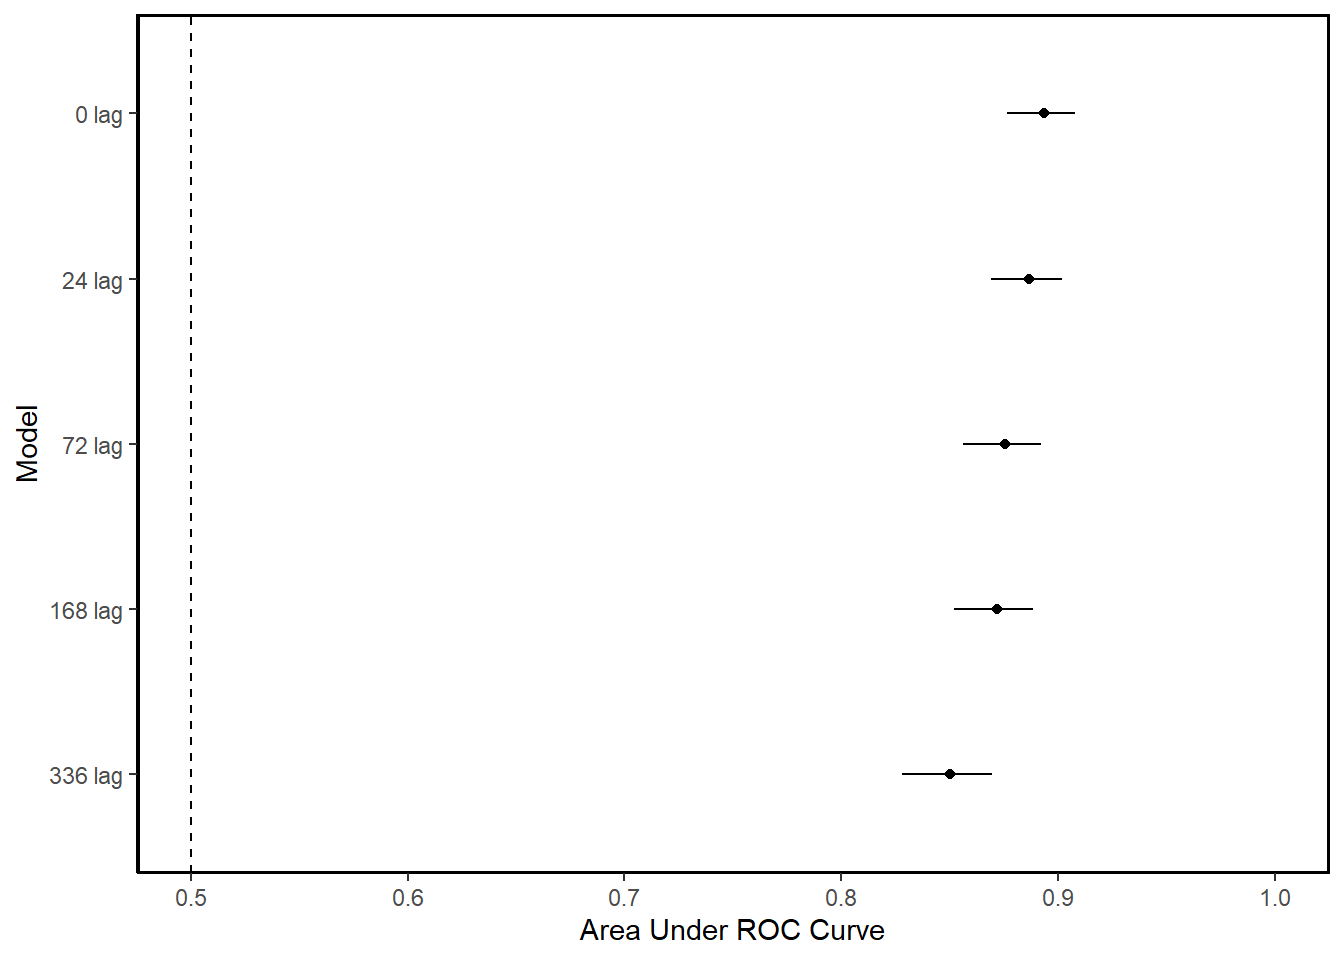

In [ ]:
#| label: fig-auroc
#| fig-cap: "Posterior probability for auROC and Bayesian credible intervals by model. Dashed line indicates a model performing at chance."

test_metrics_all_pp_perf |>
  mutate(model = factor(model, levels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" ))) |> 
  ggplot() + 
  geom_point(aes(x = pp_median, y = model), color = "black") +
  geom_segment(mapping = aes(y = model, x = pp_lower, xend = pp_upper),
                data = test_metrics_all_pp_perf) +
  scale_x_continuous("Area Under ROC Curve", limits = c(.50, 1.0)) +
  ylab("Model") +
  theme_classic() +
  theme(legend.position = "none",
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1)) +
  geom_vline(xintercept = 0.5, linetype = "dashed", color = "black")

## Figure 2: auROC differences by demographic group

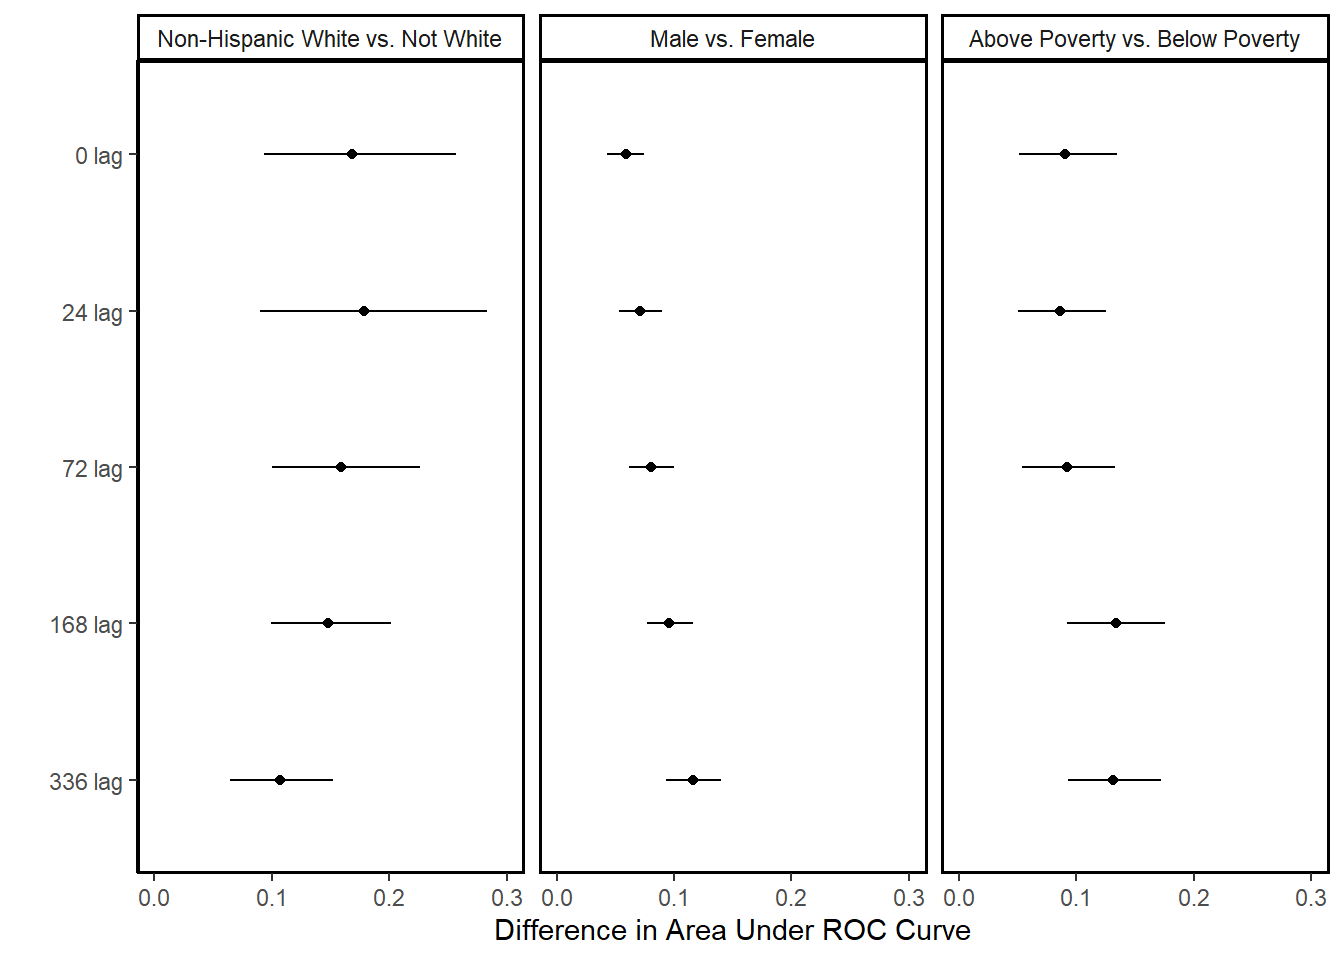

In [ ]:
#| label: fig-fairness
#| fig-cap: "Difference in auROCs by demographic group"
#| fig-width: 7

pp_dem_contrast |>
  mutate(lag = factor(lag, 
                      levels = c(336, 168, 72, 24, 0),
                      labels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" )),
         contrast = factor(contrast, levels = c("non-hispanic white vs not white",
                                                "male vs female",
                                                "above poverty vs below poverty"),
                           labels = c("Non-Hispanic White vs. Not White",
                                                "Male vs. Female",
                                                "Above Poverty vs. Below Poverty"))) |> 
  ggplot() + 
  geom_point(aes(x = median, y = lag), color = "black") +
  geom_segment(mapping = aes(y = lag, x = lower, xend = upper),
                data = pp_dem_contrast |>
                 mutate(lag = factor(lag, 
                                     levels = c(336, 168, 72, 24, 0),
                                     labels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" )),
                 contrast = factor(contrast, levels = c("non-hispanic white vs not white",
                                                "male vs female",
                                                "above poverty vs below poverty"),
                                    labels = c("Non-Hispanic White vs. Not White",
                                                "Male vs. Female",
                                                "Above Poverty vs. Below Poverty")))) +
  facet_grid(~contrast) +
  scale_x_continuous("Difference in Area Under ROC Curve", limits = c(0, .3), breaks = c(0, .1, .2, .3)) +
  ylab("") +
  theme_classic() +
  theme(legend.position = "none",
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1)) 